In [3]:
# Carga y validación de datos

import pandas as pd

# Importar los archivos CSV ---
train = pd.read_csv('Train.csv')   # Ajusta la ruta según tu estructura
test  = pd.read_csv('Test.csv')

# Verificar tipos de datos (dtypes) ---
print("Tipos de datos en Train:")
print(train.dtypes, '\n')

print("Tipos de datos en Test:")
print(test.dtypes, '\n')

# Rango de valores de columnas numéricas (describe) ---
print("Estadísticas descriptivas de Train:")
print(train.describe(), '\n')

print("Estadísticas descriptivas de Test:")
print(test.describe(), '\n')

# Conteo de valores nulos por columna ---
print("Nulos en Train:")
print(train.isnull().sum(), '\n')

print("Nulos en Test:")
print(test.isnull().sum(), '\n')

# Detección y eliminación de filas duplicadas ---
n_dup_train = train.duplicated().sum()
print(f"Filas duplicadas en Train antes de eliminar: {n_dup_train}")
train = train.drop_duplicates()
print(f"Filas duplicadas en Train después de eliminar: {train.duplicated().sum()}\n")

n_dup_test = test.duplicated().sum()
print(f"Filas duplicadas en Test antes de eliminar: {n_dup_test}")
test = test.drop_duplicates()
print(f"Filas duplicadas en Test después de eliminar: {test.duplicated().sum()}\n")

# Consistencia de IDs ---
print(f"Rango de IDs en Train: de {train['id'].min()} hasta {train['id'].max()}")
print(f"Rango de IDs en Test:  de {test['id'].min()} hasta {test['id'].max()}")
print(f"Cantidad de IDs únicos en Train: {train['id'].nunique()} (debería coincidir con número de filas)")
print(f"Cantidad de IDs únicos en Test:  {test['id'].nunique()} (debería coincidir con número de filas)")


C:\Users\Paco\AppData\Local\Temp\ipykernel_5284\1908759301.py:6: DtypeWarning: Columns (1,3,4,5,6,7,8,9,10,11,12,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('Train.csv')   # Ajusta la ruta según tu estructura


Tipos de datos en Train:
id                             int64
realSum                       object
room_type                     object
room_shared                   object
room_private                  object
person_capacity               object
host_is_superhost             object
multi                         object
biz                           object
cleanliness_rating            object
guest_satisfaction_overall    object
bedrooms                      object
dist                          object
metro_dist                    object
lng                           object
lat                           object
city                          object
day_type                      object
dtype: object 

Tipos de datos en Test:
id                              int64
room_type                      object
room_shared                      bool
room_private                     bool
person_capacity                 int64
host_is_superhost                bool
multi                           int64
biz

Nulos tras conversión numérica en Train:
realSum                       0
person_capacity               0
cleanliness_rating            0
guest_satisfaction_overall    0
bedrooms                      0
dist                          0
metro_dist                    0
lng                           0
lat                           0
dtype: int64 

Filas antes: 36194, después de quitar NaN en realSum: 36194



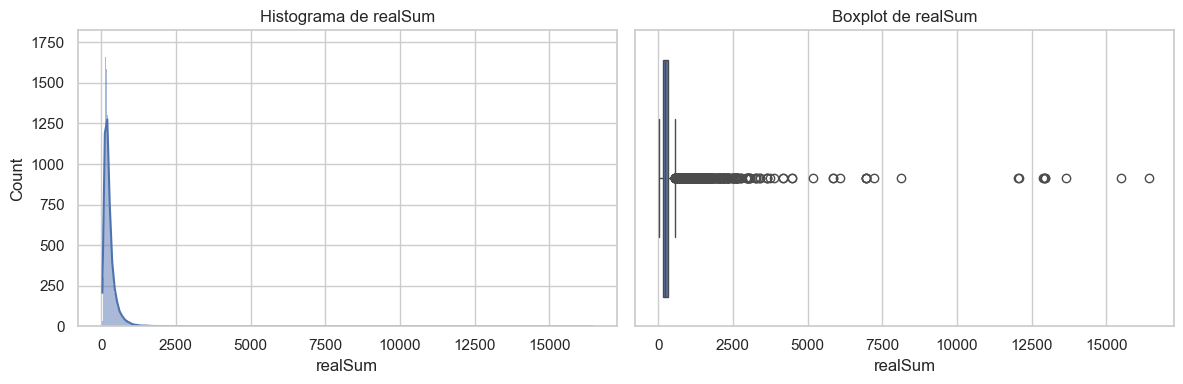

Skew de realSum: 20.55



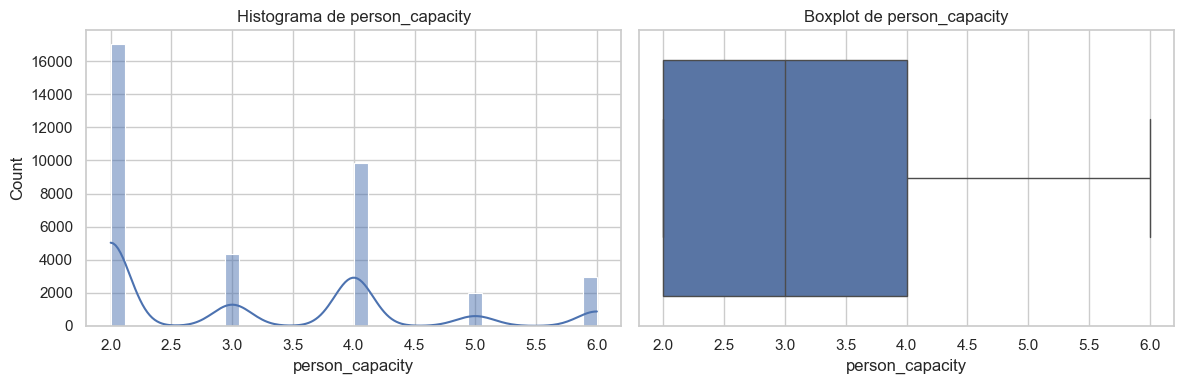

Skew de person_capacity: 0.76



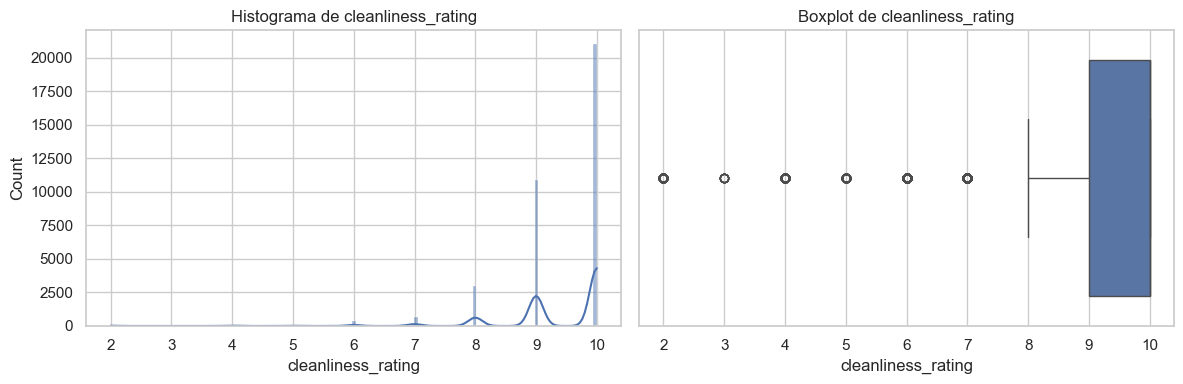

Skew de cleanliness_rating: -2.84



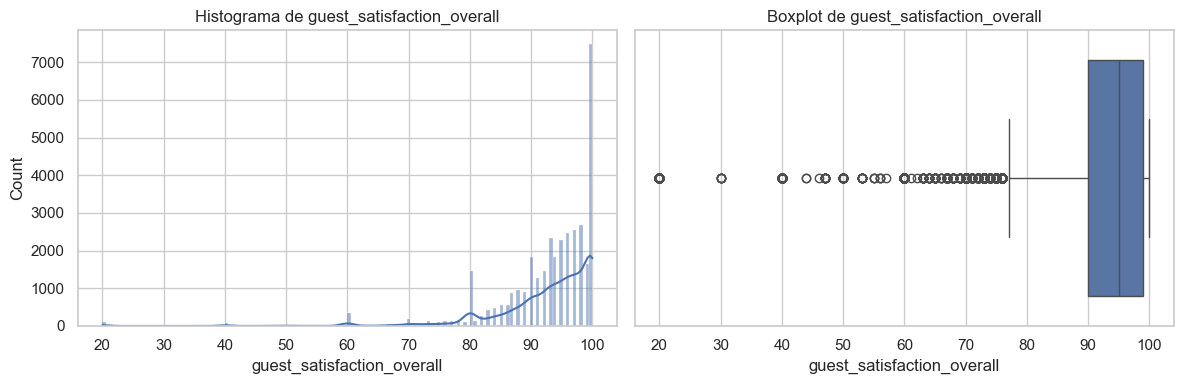

Skew de guest_satisfaction_overall: -3.15



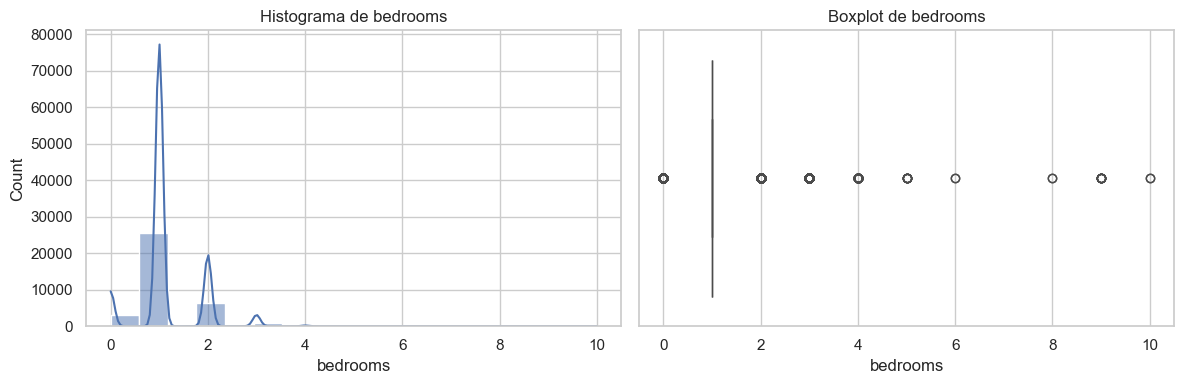

Skew de bedrooms: 1.52



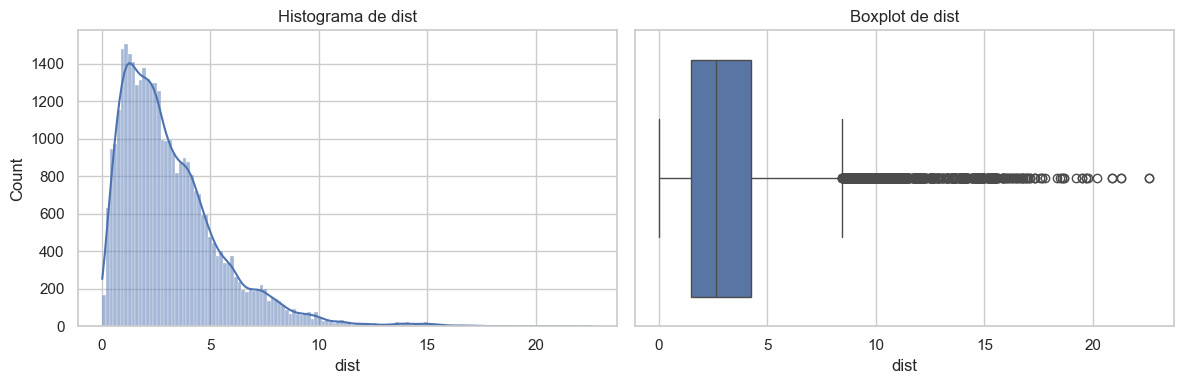

Skew de dist: 1.73



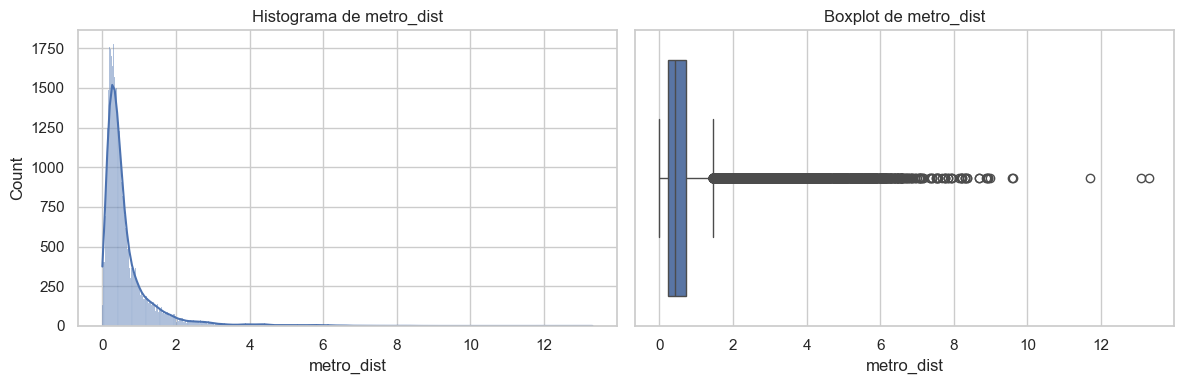

Skew de metro_dist: 4.02



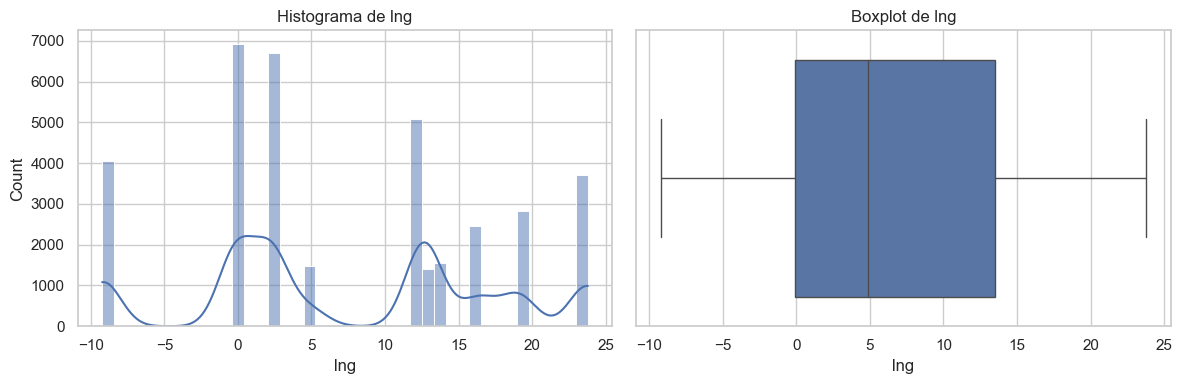

Skew de lng: 0.03



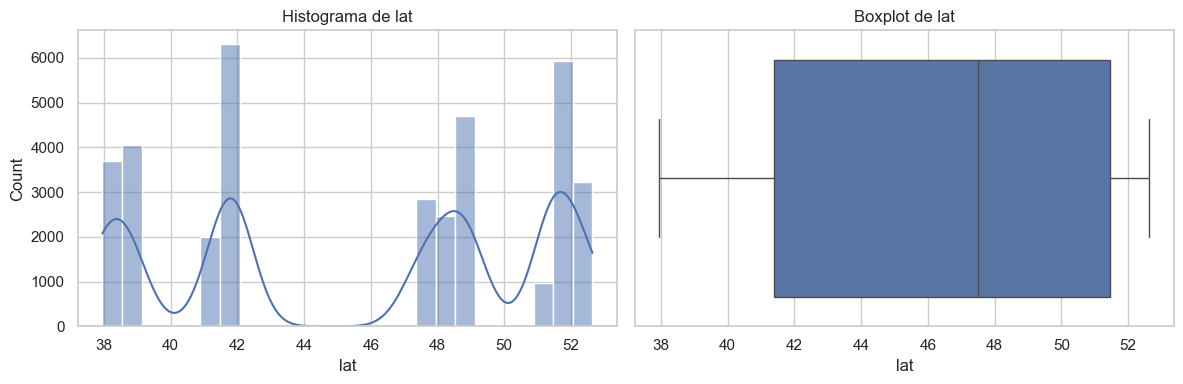

Skew de lat: -0.18



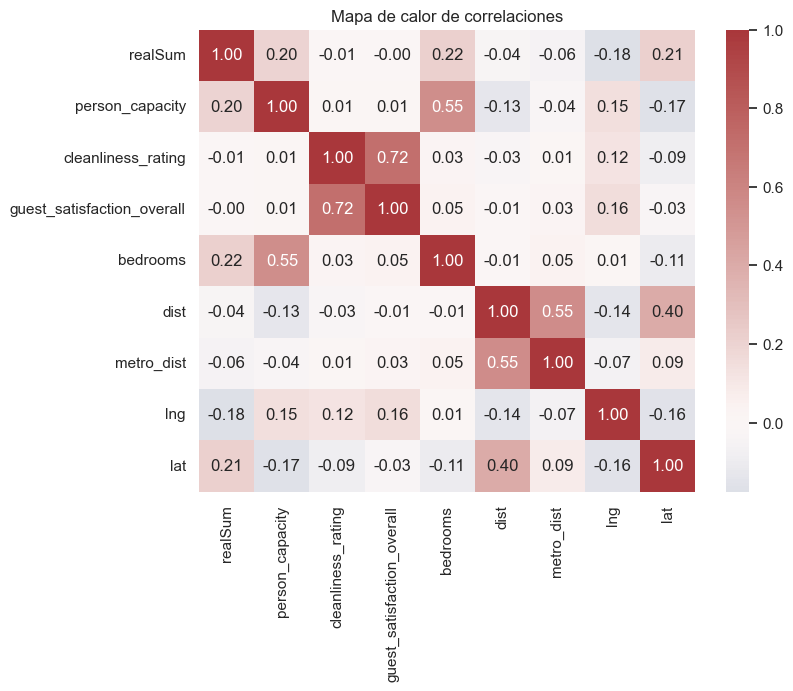

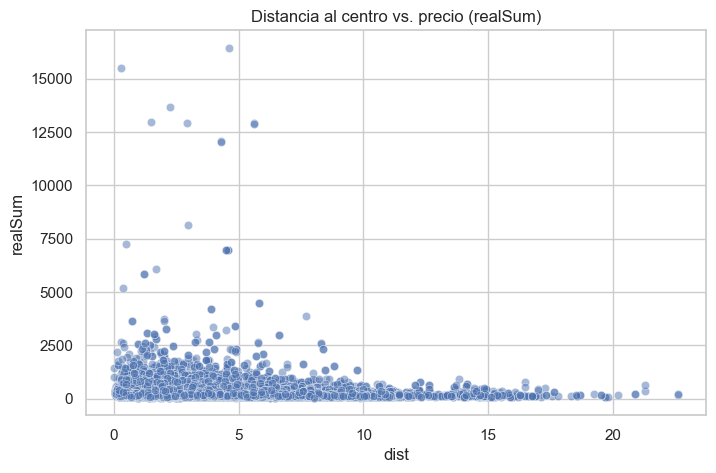

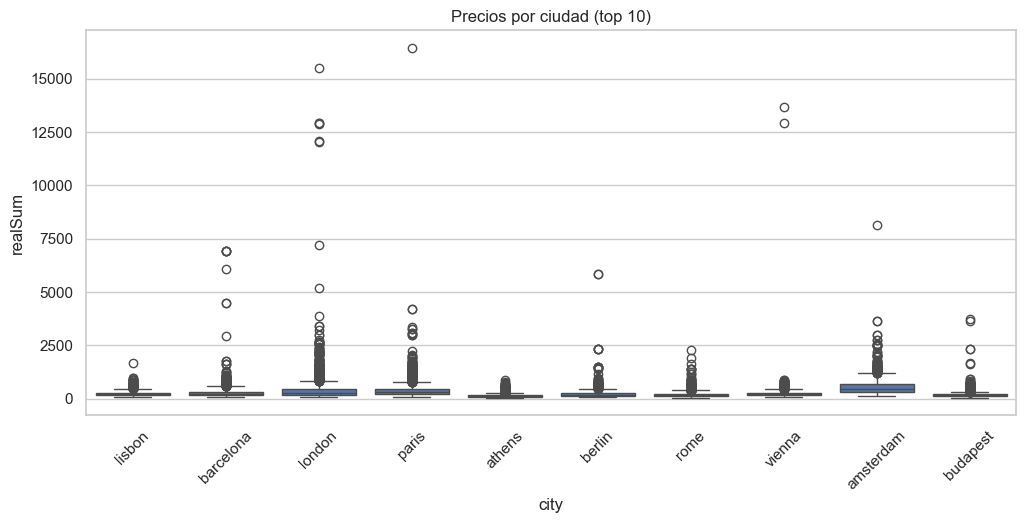

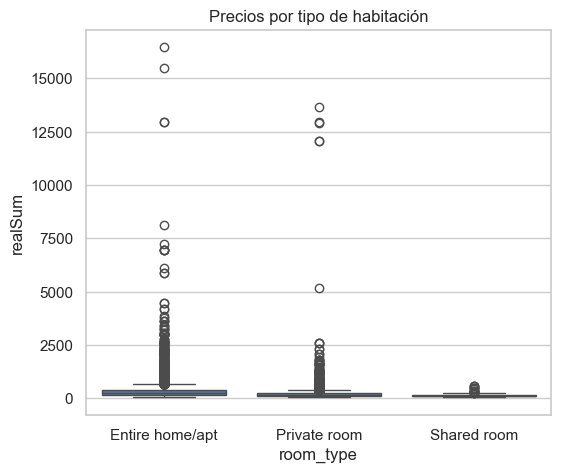

realSum: 2538 outliers (rango [-106.96, 574.66])
person_capacity: 0 outliers (rango [-1.00, 7.00])
cleanliness_rating: 1284 outliers (rango [7.50, 11.50])
guest_satisfaction_overall: 1474 outliers (rango [76.50, 112.50])
bedrooms: 10718 outliers (rango [1.00, 1.00])
dist: 1224 outliers (rango [-2.74, 8.45])
metro_dist: 3532 outliers (rango [-0.48, 1.46])
lng: 0 outliers (rango [-20.48, 33.94])
lat: 0 outliers (rango [26.29, 66.58])

Variables con skew alto (>1):
 - realSum: skew = 20.55
 - cleanliness_rating: skew = -2.84
 - guest_satisfaction_overall: skew = -3.15
 - bedrooms: skew = 1.52
 - dist: skew = 1.73
 - metro_dist: skew = 4.02


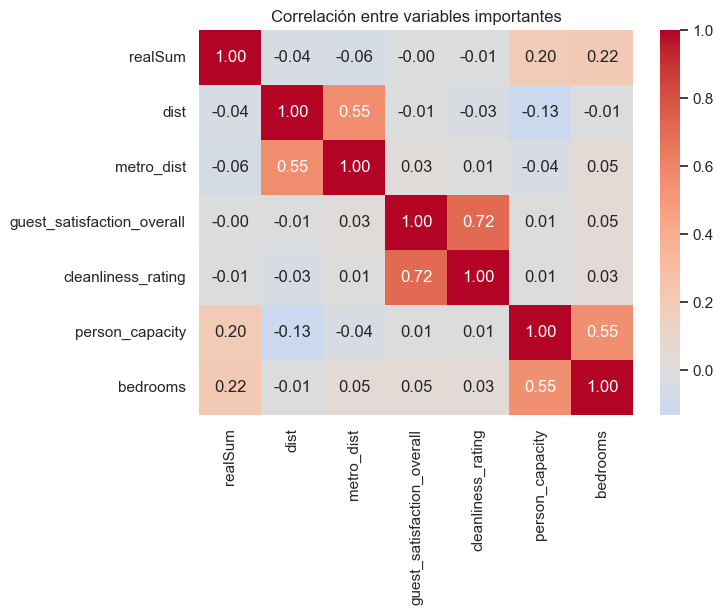

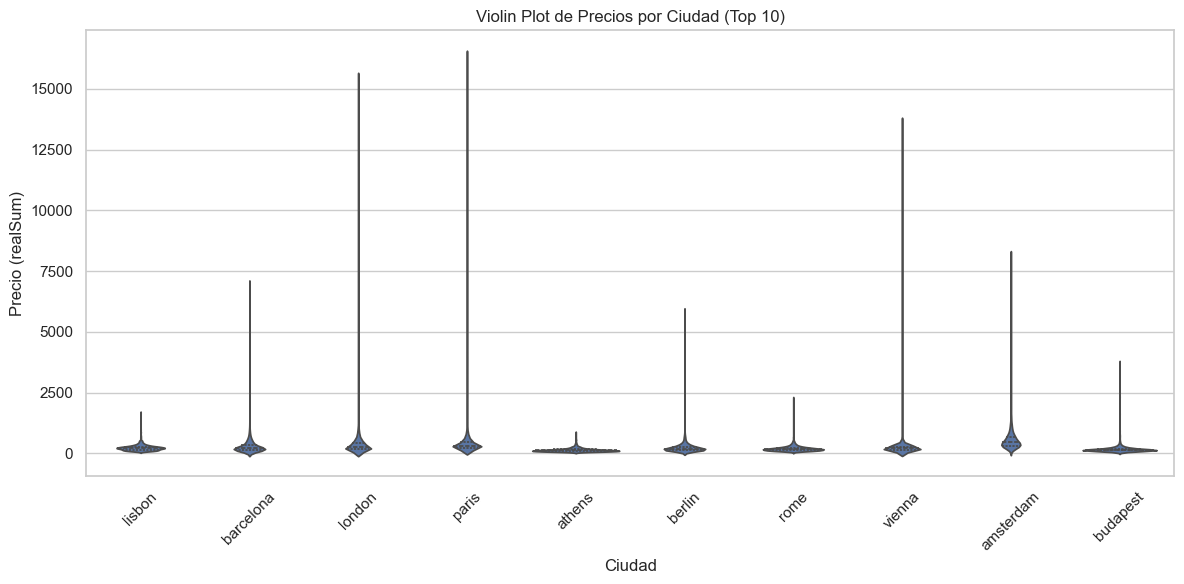

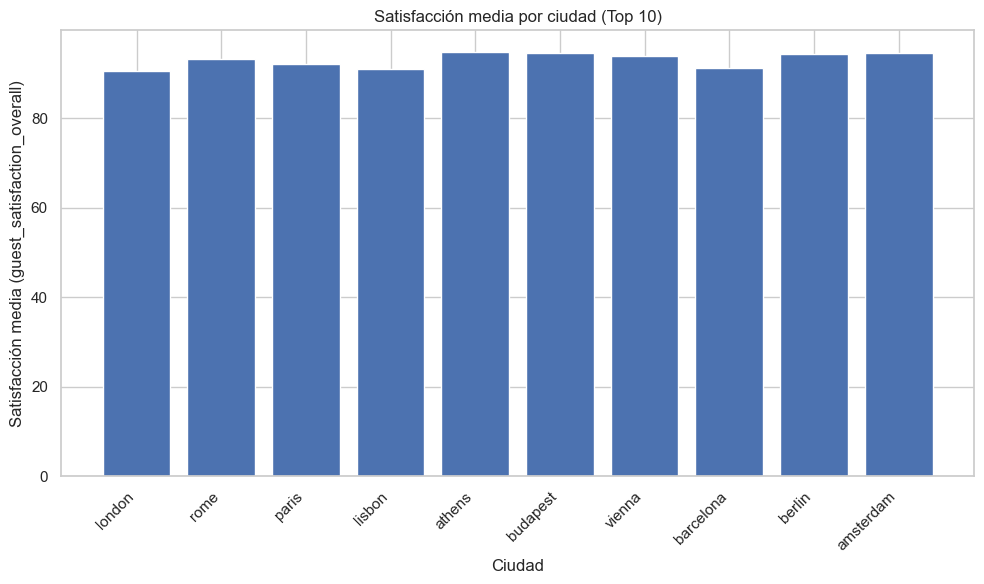

In [ ]:

# Preprocesamiento numérico previo al EDA
import pandas as pd
import numpy as np

# Unificar flags booleanos (antes de convertir numéricos)
bool_cols = ['room_shared','room_private','host_is_superhost','multi','biz']
for c in bool_cols:
    # Mapeamos únicamente los valores válidos y forzamos todo lo demás a 0
    train[c] = (train[c]
                .astype(str)
                .str.strip()
                .str.upper()
                .map({'TRUE':1, 'FALSE':0, '1':1, '0':0})
                .fillna(0)
                .astype(int))
    test[c]  = (test[c]
                .astype(str)
                .str.strip()
                .str.upper()
                .map({'TRUE':1, 'FALSE':0, '1':1, '0':0})
                .fillna(0)
                .astype(int))

# 2.7.b Convertir columnas numéricas, quitando posibles comas de miles
numeric_cols = [
    'realSum', 'person_capacity', 'cleanliness_rating',
    'guest_satisfaction_overall', 'bedrooms',
    'dist', 'metro_dist', 'lng', 'lat'
]
for col in numeric_cols:
    train[col] = (train[col]
                  .astype(str)
                  .str.replace(',', '', regex=False)
                  .pipe(pd.to_numeric, errors='coerce'))

# 2.7.c Ver cuántos NaN hemos introducido
print("Nulos tras conversión numérica en Train:")
print(train[numeric_cols].isnull().sum(), '\n')

# 2.7.d Eliminar filas sin precio válido
n_before = len(train)
train = train.dropna(subset=['realSum'])
print(f"Filas antes: {n_before}, después de quitar NaN en realSum: {len(train)}\n")

# 2.7.e Imputar el resto de numéricas con la mediana (opcional)
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='median')
train[numeric_cols] = imp.fit_transform(train[numeric_cols])

# 3. Análisis Exploratorio de Datos (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 3.1 Estadísticas univariantes
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    sns.histplot(train[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {col}')
    sns.boxplot(x=train[col], ax=axes[1])
    axes[1].set_title(f'Boxplot de {col}')
    plt.tight_layout()
    plt.show()
    print(f"Skew de {col}: {train[col].skew():.2f}\n")

# 3.2 Análisis bivariado
# 3.2.a Matriz de correlación completa
corr = train[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Mapa de calor de correlaciones")
plt.show()

# 3.2.b Distancia vs precio
plt.figure(figsize=(8,5))
sns.scatterplot(x=train['dist'], y=train['realSum'], alpha=0.5)
plt.title("Distancia al centro vs. precio (realSum)")
plt.show()

# 3.2.c Precio por ciudad (top 10)
top10 = train['city'].value_counts().nlargest(10).index
plt.figure(figsize=(12,5))
sns.boxplot(x='city', y='realSum', data=train[train['city'].isin(top10)])
plt.xticks(rotation=45)
plt.title("Precios por ciudad (top 10)")
plt.show()

# 3.2.d Precio por tipo de habitación
plt.figure(figsize=(6,5))
sns.boxplot(x='room_type', y='realSum', data=train)
plt.title("Precios por tipo de habitación")
plt.show()

# 3.3 Outliers e IQR
for col in numeric_cols:
    s = train[col]
    Q1, Q3 = s.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    count_out = ((s < lower) | (s > upper)).sum()
    print(f"{col}: {count_out} outliers (rango [{lower:.2f}, {upper:.2f}])")

# 3.3.b Variables con skew alto (>1)
high_skew = {col: train[col].skew() for col in numeric_cols if abs(train[col].skew()) > 1}
print("\nVariables con skew alto (>1):")
for col, sk in high_skew.items():
    print(f" - {col}: skew = {sk:.2f}")

# 3.4 Correlación reducida entre las más importantes
important_cols = [
    'realSum','dist','metro_dist',
    'guest_satisfaction_overall','cleanliness_rating',
    'person_capacity','bedrooms'
]
corr_imp = train[important_cols].corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr_imp, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre variables importantes")
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionamos las 10 ciudades con más registros
top10 = train['city'].value_counts().nlargest(10).index
plt.figure(figsize=(12,6))
sns.violinplot(
    x='city', 
    y='realSum', 
    data=train[train['city'].isin(top10)], 
    inner='quartile'
)
plt.xticks(rotation=45)
plt.title("Violin Plot de Precios por Ciudad (Top 10)")
plt.ylabel("Precio (realSum)")
plt.xlabel("Ciudad")
plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt

# Si aún no has cargado 'train', hazlo así (ajusta la ruta si es necesario):
# train = pd.read_csv("train.csv")

# Calcular la satisfacción media por ciudad
mean_sat = train.groupby('city')['guest_satisfaction_overall'] \
                .mean() \
                .sort_values(ascending=False)

# Tomar las 10 ciudades con más registros
top_cities = train['city'].value_counts().nlargest(10).index
mean_sat_top = mean_sat.loc[top_cities]

# Plot de barras
plt.figure(figsize=(10,6))
plt.bar(mean_sat_top.index, mean_sat_top.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Ciudad")
plt.ylabel("Satisfacción media (guest_satisfaction_overall)")
plt.title("Satisfacción media por ciudad (Top 10)")
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,4))
# Histograma
plt.subplot(1,2,1)
sns.histplot(train['guest_satisfaction_overall'], bins=10, kde=True)
plt.title("Histograma de Satisfacción")

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x=train['guest_satisfaction_overall'])
plt.title("Boxplot de Satisfacción")

plt.tight_layout()
plt.show()

In [4]:
# 4. Preprocesamiento y limpieza mejorado

import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- 4.1 Definición de columnas por tipo ---
numeric_cols = [
    'person_capacity', 'cleanliness_rating',
    'guest_satisfaction_overall', 'bedrooms',
    'dist', 'metro_dist'
]
categorical_cols = [
    'room_type', 'city', 'room_shared',
    'room_private', 'host_is_superhost',
    'multi', 'biz', 'day_type'
]
bool_cols = ['room_shared','room_private','host_is_superhost','multi','biz']

# --- 4.1.a Normalizar flags booleanos en train y test ---
for c in bool_cols:
    for df in (train, test):
        df[c] = (
            df[c].astype(str)
                 .str.strip()
                 .str.upper()
                 .map({'TRUE':1,'FALSE':0,'1':1,'0':0})
                 .fillna(0)
                 .astype(int)
        )

# --- 4.2 Agrupar categorías raras en 'city' (<1%) ---
city_counts = train['city'].value_counts(normalize=True)
rare_cities = city_counts[city_counts < 0.01].index
train['city'] = train['city'].replace(rare_cities, 'Other')
test ['city'] = test ['city'].replace(rare_cities, 'Other')

# --- 4.3 Construcción de pipelines ---

# 4.3.1 Numéricos: KNN imputación + winsorización 1–99% + escalado
def winsorize_1_99(X):
    # X: numpy array, shape (n_samples, n_features)
    lower = np.percentile(X, 1, axis=0)
    upper = np.percentile(X, 99, axis=0)
    # clip sin usar el parámetro axis explícito
    return np.minimum(np.maximum(X, lower), upper)

numeric_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('winsor', FunctionTransformer(winsorize_1_99, validate=True)),
    ('scaler', StandardScaler())
])

# 4.3.2 Categóricos: one-hot encoding (sin NaN en cats)
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 4.3.3 Unión de ambos pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# --- 4.4 Aplicar transformación a train y test ---

# 4.4.1 Separar X e y
X_train = train.drop(columns=['id', 'realSum'])
y_train = train['realSum'].astype(float)
X_test  = test.drop(columns=['id'])

# 4.4.2 Asegurar que categorías son strings
X_train[categorical_cols] = X_train[categorical_cols].astype(str)
X_test [categorical_cols] = X_test [categorical_cols].astype(str)

# 4.4.3 Ajustar y transformar
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# --- 4.5 Reconstruir DataFrames opcionales con nombres de columnas ---
ohe = preprocessor.named_transformers_['cat']['onehot']
ohe_cols = ohe.get_feature_names_out(categorical_cols)
all_cols = numeric_cols + list(ohe_cols)

df_train_proc = pd.DataFrame(X_train_proc, columns=all_cols, index=train.index)
df_test_proc  = pd.DataFrame(X_test_proc, columns=all_cols, index=test.index)

# Ahora:
# - df_train_proc, y_train  listos para modelado
# - df_test_proc             listos para generación de submission


In [5]:
# 5. Ingeniería de características

import numpy as np

# 5.1 Combinación de distancias
# Creamos una nueva variable total_dist = dist + metro_dist
train['total_dist'] = train['dist'] + train['metro_dist']
test ['total_dist'] = test ['dist'] + test ['metro_dist']

# 5.2 Transformación log1p para exploración
# Sólo para EDA, no se incluye en X_train_proc salvo que uses modelos lineales
train['log_realSum'] = np.log1p(train['realSum'])

# 5.3 Interacción capacidad × dormitorios
# Captura “densidad” de ocupación: más personas por habitación
train['cap_bedrooms'] = train['person_capacity'] * train['bedrooms']
test ['cap_bedrooms'] = test ['person_capacity'] * test ['bedrooms']

# 5.4 Guardar datasets procesados
# Asegúrate de tener la carpeta data/processed/ creada
train.to_csv('train_processed.csv', index=False)
test .to_csv('test_processed.csv',  index=False)

print("Feature engineering completada y archivos guardados.")  


Feature engineering completada y archivos guardados.


In [6]:
# 6. Selección de modelo con MAE y MSE

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
import xgboost as xgb
import lightgbm as lgb

# Definir validación cruzada k=5
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Diccionario de modelos a evaluar
models = {
    'LinearRegression': LinearRegression(),
    'Ridge':             Ridge(random_state=42),
    'Lasso':             Lasso(random_state=42),
    'DecisionTree':      DecisionTreeRegressor(random_state=42),
    'RandomForest':      RandomForestRegressor(n_estimators=100, random_state=42),
    'ExtraTrees':        ExtraTreesRegressor(n_estimators=100, random_state=42),
    'GradientBoosting':  GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'XGBoost':           xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0),
    'LightGBM':          lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'SVR':               SVR(kernel='rbf', C=1.0, epsilon=0.1),
}

# Asumiendo que X_train_proc y y_train ya están definidos:
# X_train_proc: numpy array o DataFrame con features procesadas
# y_train: vector o Series con la variable objetivo realSum

results = []
for name, model in models.items():
    # Ejecutar cross_validate para MAE y MSE
    cv_results = cross_validate(
        model,
        X_train_proc, y_train,
        scoring={'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error'},
        cv=kf,
        return_train_score=False,
        n_jobs=-1
    )
    # Convertir a valores positivos
    mae_scores = -cv_results['test_MAE']
    mse_scores = -cv_results['test_MSE']
    
    results.append({
        'model':      name,
        'MAE_mean':   np.mean(mae_scores),
        'MAE_std':    np.std(mae_scores),
        'MSE_mean':   np.mean(mse_scores),
        'MSE_std':    np.std(mse_scores),
    })
    
    # Mostrar en consola
    print(f"{name}: "
          f"MAE = {np.mean(mae_scores):.2f} ± {np.std(mae_scores):.2f} | "
          f"MSE = {np.mean(mse_scores):.2f} ± {np.std(mse_scores):.2f}")

# Crear DataFrame de resultados y ordenarlo por MAE (o por la métrica que prefieras)
df_results = pd.DataFrame(results).sort_values('MAE_mean').reset_index(drop=True)

print("\nResumen de MAE y MSE por modelo:")
print(df_results)

# Opcional: guardar resultados
df_results.to_csv('model_selection_results.csv', index=False)


LinearRegression: MAE = 102.84 ± 2.05 | MSE = 83473.33 ± 13237.40
Ridge: MAE = 102.83 ± 2.05 | MSE = 83473.28 ± 13237.37
Lasso: MAE = 101.30 ± 2.11 | MSE = 83752.97 ± 13191.66
DecisionTree: MAE = 76.47 ± 2.80 | MSE = 118432.75 ± 32270.84
RandomForest: MAE = 68.29 ± 2.48 | MSE = 60261.74 ± 14588.81
ExtraTrees: MAE = 69.67 ± 2.07 | MSE = 63641.01 ± 16257.57
GradientBoosting: MAE = 84.63 ± 2.22 | MSE = 74878.35 ± 14110.09
XGBoost: MAE = 78.80 ± 2.14 | MSE = 60414.17 ± 16147.30
LightGBM: MAE = 82.97 ± 2.02 | MSE = 69493.03 ± 12462.84
SVR: MAE = 97.69 ± 2.16 | MSE = 94613.30 ± 13677.46

Resumen de MAE y MSE por modelo:
              model    MAE_mean   MAE_std       MSE_mean       MSE_std
0      RandomForest   68.292030  2.482926   60261.743976  14588.807157
1        ExtraTrees   69.669483  2.068640   63641.008365  16257.572439
2      DecisionTree   76.469550  2.804426  118432.748358  32270.842529
3           XGBoost   78.798794  2.143315   60414.171186  16147.303709
4          LightGBM   8

In [ ]:
# 7. Entrenamiento final: ajuste de hiperparámetros para los 6 mejores modelos
import numpy as np
import joblib
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Asumimos disponibles en memoria:
#   X_train_proc: array de features procesadas
#   y_train:      array (o Serie) de target realSum

# 7.1 Define los modelos y sus espacios de hiperparámetros
model_spaces = {
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators':      randint(200, 1200),
            'max_depth':         randint(10, 60),
            'max_features':      uniform(0.3, 0.7),
            'min_samples_split': randint(2, 20),
            'min_samples_leaf':  randint(1, 20),
            'bootstrap':         [True, False]
        }
    },
    'ExtraTrees': {
        'model': ExtraTreesRegressor(random_state=42),
        'params': {
            'n_estimators':      randint(200, 1200),
            'max_depth':         randint(10, 60),
            'max_features':      uniform(0.3, 0.7),
            'min_samples_split': randint(2, 20),
            'min_samples_leaf':  randint(1, 20),
            'bootstrap':         [True, False]    # añadido bootstrap opcional
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'n_estimators':      randint(100, 800),
            'learning_rate':     uniform(0.01, 0.19),
            'max_depth':         randint(3, 10),
            'subsample':         uniform(0.6, 0.4),
            'min_samples_split': randint(2, 20),
            'min_samples_leaf':  randint(1, 20),
        }
    },
    'XGBoost': {
        'model': XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1),
        'params': {
            'n_estimators':      randint(100, 1000),
            'learning_rate':     uniform(0.01, 0.19),
            'max_depth':         randint(3, 12),
            'subsample':         uniform(0.6, 0.4),
            'colsample_bytree':  uniform(0.6, 0.4),
            'gamma':             uniform(0, 5),
            'min_child_weight':  randint(1, 20)
        }
    }, 
}

# 7.2 Función para ajustar cada modelo
def tune_model(name, model, param_dist, X, y, n_iter=60):
    rs = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring='neg_mean_absolute_error',
        cv=5,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    rs.fit(X, y)
    best = rs.best_estimator_
    best_mae = -rs.best_score_
    print(f"{name} → MAE_CV: {best_mae:.2f}, params: {rs.best_params_}")
    return name, best, best_mae

# 7.3 Ejecutar tuning para todos los modelos
tuned_models = {}
for name, spec in model_spaces.items():
    nm, mdl, mae = tune_model(
        name,
        spec['model'],
        spec['params'],
        X_train_proc,
        y_train,
        n_iter=60
    )
    tuned_models[nm] = (mdl, mae)
    joblib.dump(mdl, f"{nm.lower()}_final.pkl")

# 7.4 Resumen de los mejores modelos
print("\nResumen de MAE después de tuning:")
for name, (_, mae) in tuned_models.items():
    print(f" - {name}: MAE_CV = {mae:.2f}")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
RandomForest → MAE_CV: 67.92, params: {'bootstrap': False, 'max_depth': 31, 'max_features': np.float64(0.9210489198034286), 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 812}
Fitting 5 folds for each of 60 candidates, totalling 300 fits
ExtraTrees → MAE_CV: 71.83, params: {'bootstrap': False, 'max_depth': 31, 'max_features': np.float64(0.9210489198034286), 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 812}
Fitting 5 folds for each of 60 candidates, totalling 300 fits
GradientBoosting → MAE_CV: 72.26, params: {'learning_rate': np.float64(0.1518333669724246), 'max_depth': 9, 'min_samples_leaf': 3, 'min_samples_split': 18, 'n_estimators': 739, 'subsample': np.float64(0.8273234413341887)}
Fitting 5 folds for each of 60 candidates, totalling 300 fits


c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\xgboost\core.py", line 729, in inner_f
    return func(**kwargs)
  File "c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\xgboost\sklearn.py", line 1222,

XGBoost → MAE_CV: 72.35, params: {'colsample_bytree': np.float64(0.9720067339243328), 'gamma': np.float64(0.3520806542477195), 'learning_rate': np.float64(0.04969455634691844), 'max_depth': 8, 'min_child_weight': 2, 'n_estimators': 738, 'subsample': np.float64(0.8073318609454947)}
Fitting 5 folds for each of 60 candidates, totalling 300 fits


KeyboardInterrupt: 

In [24]:
# --- 12. Guardar los modelos afinados con los mejores hiperparámetros ---

import joblib
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Asumimos que X_train_proc y y_train ya están en memoria, procesados y listos.

# 12.1 Definir cada modelo con sus mejores parámetros (de RandomizedSearchCV)
rf_best = RandomForestRegressor(
    n_estimators=812,
    max_depth=31,
    max_features=0.9210489198034286,
    min_samples_split=4,
    min_samples_leaf=1,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

et_best = ExtraTreesRegressor(
    n_estimators=812,
    max_depth=31,
    max_features=0.9210489198034286,
    min_samples_split=4,
    min_samples_leaf=1,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

gb_best = GradientBoostingRegressor(
    n_estimators=739,
    learning_rate=0.1518333669724246,
    max_depth=9,
    subsample=0.8273234413341887,
    min_samples_split=18,
    min_samples_leaf=3,
    random_state=42
)

xgb_best = XGBRegressor(
    n_estimators=738,
    learning_rate=0.04969455634691844,
    max_depth=8,
    subsample=0.8073318609454947,
    colsample_bytree=0.9720067339243328,
    gamma=0.3520806542477195,
    min_child_weight=2,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

lgbm_best = LGBMRegressor(
    # Asumiendo valores por defecto para LGBM, o reemplaza según tu tuning
    objective='regression',
    metric='mae',
    random_state=42,
    n_jobs=-1
    # aquí irían los hyperparams si los tuvieras
)

# 12.2 Entrenar cada uno sobre todo el conjunto de entrenamiento
for name, model in [
    ('random_forest', rf_best),
    ('extra_trees',  et_best),
    ('grad_boost',   gb_best),
    ('xgboost',      xgb_best),
    ('lightgbm',     lgbm_best),
]:
    print(f"Entrenando {name}...")
    model.fit(X_train_proc, y_train)
    fname = f"{name}_final.pkl"
    joblib.dump(model, fname)
    print(f"  → Modelo guardado en '{fname}'")


Entrenando random_forest...
  → Modelo guardado en 'random_forest_final.pkl'
Entrenando extra_trees...
  → Modelo guardado en 'extra_trees_final.pkl'
Entrenando grad_boost...
  → Modelo guardado en 'grad_boost_final.pkl'
Entrenando xgboost...
  → Modelo guardado en 'xgboost_final.pkl'
Entrenando lightgbm...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002017 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 617
[LightGBM] [Info] Number of data points in the train set: 36194, number of used features: 31
[LightGBM] [Info] Start training from score 279.386846
  → Modelo guardado en 'lightgbm_final.pkl'


MAE en hold-out: 61.44


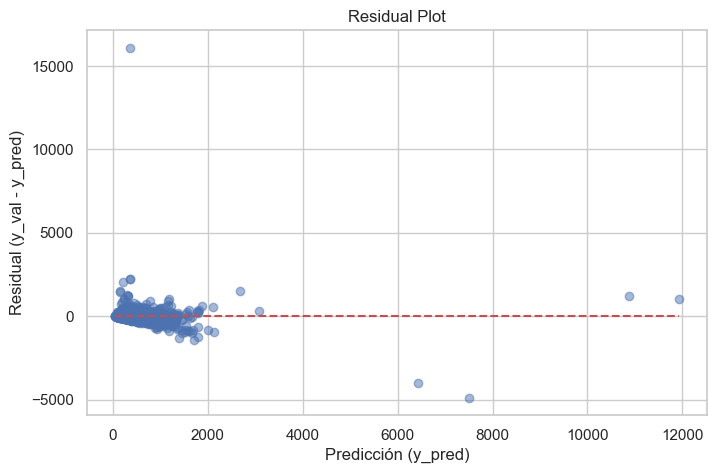

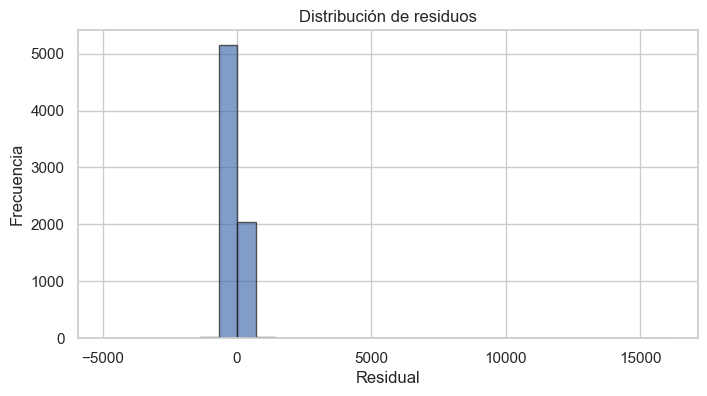

In [16]:
# 8. Evaluación de desempeño

import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# --- 8.1 Crear un hold-out interno (80% train / 20% val) ---
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_proc, y_train,
    test_size=0.2,
    random_state=42
)

# --- 8.2 Entrenar el modelo final optimizado (por ejemplo RandomForest) en X_tr ---
# asumimos que `best_rf` o el objeto afinado esté en memoria
best_rf.fit(X_tr, y_tr)

# --- 8.3 Predecir sobre hold-out ---
y_pred = best_rf.predict(X_val)

# --- 8.4 Calcular MAE ---
mae = mean_absolute_error(y_val, y_pred)
print(f"MAE en hold-out: {mae:.2f}")

# --- 8.5 Graficar residuos para detectar sesgos ---
residuals = y_val - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.hlines(0, xmin=y_pred.min(), xmax=y_pred.max(), colors='r', linestyles='--')
plt.xlabel("Predicción (y_pred)")
plt.ylabel("Residual (y_val - y_pred)")
plt.title("Residual Plot")
plt.show()

# Opcional: histograma de residuos
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel("Residual")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos")
plt.show()


In [14]:
# 11. Generación de la submission (corregido)

import pandas as pd
import numpy as np
import joblib

# --- 11.1 Cargar el test crudo ---
test_raw = pd.read_csv('Test.csv')  # el original sin encoding ni imputación

# --- 11.2 Feature engineering idéntico a train ---
# 11.2.1 Agrupar ciudades raras (<1%)
city_counts = test_raw['city'].value_counts(normalize=True)
rare_cities = city_counts[city_counts < 0.01].index
test_raw['city'] = test_raw['city'].replace(rare_cities, 'Other')

# 11.2.2 Variable total_dist
test_raw['total_dist'] = test_raw['dist'] + test_raw['metro_dist']

# 11.2.3 Interacción capacity × bedrooms
test_raw['cap_bedrooms'] = test_raw['person_capacity'] * test_raw['bedrooms']

# --- 11.3 Preprocesamiento idéntico a train ---
# Suponiendo que 'preprocessor' y 'categorical_cols' siguen en memoria:
# (si no, vuelve a definirlo exactamente como en el paso 4)

# Convertir booleanos/categóricas a str
for col in categorical_cols:
    test_raw[col] = test_raw[col].astype(str)

# Seleccionar únicamente las columnas de input:
X_test = test_raw.drop(columns=['id'])  # sin el id

# Aplicar el ColumnTransformer entrenado en train:
X_test_proc = preprocessor.transform(X_test)

# --- 11.4 Cargar el modelo afinado y predecir ---
best_rf = joblib.load('randomforest_final.pkl')
realSum_pred = best_rf.predict(X_test_proc)

# --- 11.5 Construir y guardar submission.csv ---
submission = pd.DataFrame({
    'id':       test_raw['id'],
    'realSum':  realSum_pred
})

# Verificar que tenga 15 513 filas
assert len(submission) == 15513, f"Esperaba 15513 filas, encontradas {len(submission)}"

submission.to_csv('submission.csv', index=False)
print("submission.csv generado correctamente.")  
print(submission.head())


submission.csv generado correctamente.
      id      realSum
0  36196   391.087236
1  36197  1060.966933
2  36198  1058.198210
3  36199   138.918704
4  36200   311.399664


In [ ]:
# =============================================================================
# 1. Mejora de la estabilidad y reducción de varianza con Bagging y RandomizedSearch
# =============================================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.tree      import DecisionTreeRegressor
from sklearn.ensemble  import BaggingRegressor
from sklearn.metrics   import mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# --- 1.1 Carga de datos numéricos procesados ---
df = pd.read_csv('train_bagging.csv')  
y  = df['realSum'].values
X  = df.drop(columns=['id','realSum']).values

# --- 1.2 Definir el árbol base más profundo para reducir bias ---
base_tree = DecisionTreeRegressor(max_depth=None,   # sin límite de profundidad
                                  min_samples_leaf=1,
                                  random_state=42)

# --- 1.3 Espacio de búsqueda de hiperparámetros ---
param_dist = {
    'n_estimators':   randint(100, 600),
    'max_samples':    uniform(0.5, 0.5),    # de 0.5 a 1.0
    'max_features':   uniform(0.5, 0.5),    # de 0.5 a 1.0
    'bootstrap':      [True],
    'bootstrap_features': [True, False],
    'estimator__max_depth':       [None, 10, 20, 30],
    'estimator__min_samples_leaf':[1, 2, 5]
}

bag = BaggingRegressor(
    estimator=base_tree,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

# --- 1.4 RandomizedSearchCV para encontrar la mejor combinación ---
search = RandomizedSearchCV(
    estimator=bag,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search.fit(X, y)

print("Mejores parámetros encontrados:")
print(search.best_params_)
print("Mejor MAE (CV negativo):", -search.best_score_)

# --- 1.5 Entrenar el modelo final con los mejores hiperparámetros ---
best_bag = search.best_estimator_
best_bag.fit(X, y)

# --- 1.6 Guardar el modelo definitivo ---
joblib.dump(best_bag, 'bagging_improved_final.pkl')
print("Modelo Bagging mejorado guardado en 'bagging_improved_final.pkl'.")


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Mejores parámetros encontrados:
{'bootstrap': True, 'bootstrap_features': False, 'estimator__max_depth': 20, 'estimator__min_samples_leaf': 1, 'max_features': np.float64(0.7933755828319241), 'max_samples': np.float64(0.982627653632069), 'n_estimators': 287}
Mejor MAE (CV negativo): 70.19821443818572
Modelo Bagging mejorado guardado en 'bagging_improved_final.pkl'.


In [43]:
# =============================================================================
# 2. Ensambles adicionales: Random Patches, Random Subspaces y ExtraTrees
# =============================================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.tree           import DecisionTreeRegressor
from sklearn.ensemble       import BaggingRegressor, ExtraTreesRegressor
from sklearn.metrics        import mean_absolute_error

# --- 2.1 Carga de datos bagging-ready ---
df = pd.read_csv('train_bagging.csv')
y  = df['realSum'].values
X  = df.drop(columns=['id','realSum']).values

# -----------------------------------------------------------------------------
# 2.2 Random Patches: bootstrap filas + muestreo de columnas
# -----------------------------------------------------------------------------
# Usamos los mejores parámetros hallados previamente como base
base_tree = DecisionTreeRegressor(max_depth=20, min_samples_leaf=1, random_state=42)

rp = BaggingRegressor(
    estimator          = base_tree,
    n_estimators       = 287,                   # mejor n_estimators
    max_samples        = 0.9826,                # mejor max_samples
    max_features       = 0.7934,                # reducimos columnas
    bootstrap          = True,                  # muestreo de filas
    bootstrap_features = True,                  # muestreo de columnas
    oob_score          = True,
    random_state       = 42,
    n_jobs             = -1
)
rp.fit(X, y)

oob_pred_rp = rp.oob_prediction_
mae_rp = mean_absolute_error(y, oob_pred_rp)
print(f"Random Patches → OOB MAE = {mae_rp:.2f}")

# -----------------------------------------------------------------------------
# 2.3 Random Subspaces: todas las filas + muestreo de columnas
# -----------------------------------------------------------------------------
rs = BaggingRegressor(
    estimator          = base_tree,
    n_estimators       = 287,
    max_samples        = 1.0,       # todas las filas
    max_features       = 0.6,       # subsample columnas más pequeño
    bootstrap          = False,     # sin muestreo de filas
    bootstrap_features = True,      # sí muestreo de columnas
    oob_score          = False,     # OOB no aplicable sin bootstrap filas
    random_state       = 42,
    n_jobs             = -1
)
rs.fit(X, y)
# No hay oob_prediction_ cuando bootstrap=False
# Estimamos MAE interno con CV rápido si queremos:
from sklearn.model_selection import cross_val_predict, KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
pred_rs = cross_val_predict(rs, X, y, cv=kf, n_jobs=-1)
mae_rs = mean_absolute_error(y, pred_rs)
print(f"Random Subspaces → CV MAE = {mae_rs:.2f}")

# -----------------------------------------------------------------------------
# 2.4 ExtraTreesRegressor con OOB
# -----------------------------------------------------------------------------
# ExtraTreesRegressor también soporta oob_score
et = ExtraTreesRegressor(
    n_estimators       = 287,
    max_depth          = 20,
    min_samples_leaf   = 1,
    max_features       = 0.6,
    bootstrap          = True,
    oob_score          = True,
    random_state       = 42,
    n_jobs             = -1
)
et.fit(X, y)

oob_pred_et = et.oob_prediction_
mae_et = mean_absolute_error(y, oob_pred_et)
print(f"ExtraTrees → OOB MAE = {mae_et:.2f}")

# -----------------------------------------------------------------------------
# 2.5 Comparativa y guardado
# -----------------------------------------------------------------------------
results = pd.DataFrame([
    {'model':'RandomPatches', 'OOB/CV_MAE': mae_rp},
    {'model':'RandomSubspaces','OOB/CV_MAE': mae_rs},
    {'model':'ExtraTrees',     'OOB/CV_MAE': mae_et},
])
print("\nComparativa de MAEs:")
print(results)

# Guardar los modelos si quieres
joblib.dump(rp, 'bagging_random_patches.pkl')
joblib.dump(rs, 'bagging_random_subspaces.pkl')
joblib.dump(et, 'extratrees_oob.pkl')


Random Patches → OOB MAE = 79.52
Random Subspaces → CV MAE = 83.87
ExtraTrees → OOB MAE = 77.39

Comparativa de MAEs:
             model  OOB/CV_MAE
0    RandomPatches   79.517520
1  RandomSubspaces   83.870047
2       ExtraTrees   77.394361


['extratrees_oob.pkl']

In [51]:
# =============================================================================
# 3. Boosting: corregir errores secuencialmente
# =============================================================================

import numpy as np
import pandas as pd
import joblib

from sklearn.tree             import DecisionTreeRegressor
from sklearn.ensemble         import AdaBoostRegressor, GradientBoostingRegressor
from sklearn.metrics          import mean_absolute_error
from sklearn.model_selection  import train_test_split

import xgboost as xgb

# --- 3.0 Preparar hold‐out interno ---
# Partición 80/20 para validar early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_proc, y_train,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------------------------------
# 3.1 AdaBoostRegressor (stumps)
# ------------------------------------------------------------------------
# Definir stump
stump = DecisionTreeRegressor(max_depth=1, random_state=42)

ada = AdaBoostRegressor(
    estimator=stump,            # scikit-learn 1.2+ usa `estimator` en lugar de base_estimator
    n_estimators=200,           # prueba [50,100,200…]
    learning_rate=0.1,          # prueba [0.01,0.1,1.0]
    random_state=42
)
ada.fit(X_tr, y_tr)
y_pred_ada = ada.predict(X_val)
mae_ada    = mean_absolute_error(y_val, y_pred_ada)
print(f"AdaBoost → MAE validación: {mae_ada:.2f}")

# ------------------------------------------------------------------------
# 3.2 GradientBoostingRegressor con warm_start y early stopping manual
# ------------------------------------------------------------------------
gbr = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    warm_start=True            # permite incrementar árboles
)

best_iter = 0
best_mae  = np.inf
no_improve = 0

for n in range(50, 1001, 50):
    gbr.n_estimators = n
    gbr.fit(X_tr, y_tr)
    y_pred_gbr = gbr.predict(X_val)
    mae_gbr    = mean_absolute_error(y_val, y_pred_gbr)
    print(f"GBR n_estimators={n} → MAE={mae_gbr:.2f}")
    if mae_gbr < best_mae:
        best_mae = mae_gbr
        best_iter = n
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= 5:
            break

print(f"→ Mejor GBR: n_estimators={best_iter}, MAE={best_mae:.2f}")

# Reentrenar sobre todo el set con best_iter
gbr_final = GradientBoostingRegressor(
    n_estimators=best_iter,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr_final.fit(np.vstack([X_tr, X_val]), np.concatenate([y_tr, y_val]))
joblib.dump(gbr_final, 'gbr_final.pkl')
print("GBR final guardado en 'gbr_final.pkl'.")

# ------------------------------------------------------------------------
# 3.3 XGBoost con early stopping usando la API nativa
# ------------------------------------------------------------------------
# Convertir a DMatrix
dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval   = xgb.DMatrix(X_val, label=y_val)

# Parámetros
params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.05,
    'max_depth': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'mae',
    'seed': 42
}

# Entrenamiento con early stopping
evals_result = {}
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dval, 'validation')],
    early_stopping_rounds=20,
    evals_result=evals_result,
    verbose_eval=False
)

best_iter_xgb = bst.best_iteration + 1
best_mae_xgb  = evals_result['validation']['mae'][bst.best_iteration]
print(f"XGBoost → mejor n_estimators = {best_iter_xgb}, MAE validación = {best_mae_xgb:.2f}")

# Reentrenar en todo
dfull = xgb.DMatrix(np.vstack([X_tr, X_val]), label=np.concatenate([y_tr, y_val]))
bst_final = xgb.train(
    params,
    dfull,
    num_boost_round=best_iter_xgb
)
bst_final.save_model('xgb_final.model')
print("XGBoost final guardado en 'xgb_final.model'.")


AdaBoost → MAE validación: 284.64
GBR n_estimators=50 → MAE=100.12
GBR n_estimators=100 → MAE=91.15
GBR n_estimators=150 → MAE=87.59
GBR n_estimators=200 → MAE=85.89
GBR n_estimators=250 → MAE=85.19
GBR n_estimators=300 → MAE=84.87
GBR n_estimators=350 → MAE=84.64
GBR n_estimators=400 → MAE=84.27
GBR n_estimators=450 → MAE=83.94
GBR n_estimators=500 → MAE=83.71
GBR n_estimators=550 → MAE=83.49
GBR n_estimators=600 → MAE=83.37
GBR n_estimators=650 → MAE=83.40
GBR n_estimators=700 → MAE=83.33
GBR n_estimators=750 → MAE=83.35
GBR n_estimators=800 → MAE=83.24
GBR n_estimators=850 → MAE=83.14
GBR n_estimators=900 → MAE=83.17
GBR n_estimators=950 → MAE=83.17
GBR n_estimators=1000 → MAE=83.24
→ Mejor GBR: n_estimators=850, MAE=83.14
GBR final guardado en 'gbr_final.pkl'.
XGBoost → mejor n_estimators = 278, MAE validación = 84.64
XGBoost final guardado en 'xgb_final.model'.


C:\Users\Paco\AppData\Local\Temp\ipykernel_14892\3004315521.py:125: UserWarning: [20:29:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  bst_final.save_model('xgb_final.model')


In [13]:
# =============================================================================
# 4. Selección de variables y reducción de dimensionalidad
# =============================================================================

import numpy as np
import pandas as pd
import joblib

from sklearn.ensemble            import RandomForestRegressor
from sklearn.feature_selection   import SelectFromModel
from sklearn.decomposition       import PCA
from sklearn.pipeline            import Pipeline
from sklearn.compose             import ColumnTransformer
from sklearn.preprocessing       import StandardScaler

# --- 4.1 Carga del modelo final previamente entrenado ---
# (puede ser RandomForest o ExtraTrees)
best_rf = joblib.load('randomforest_final.pkl')

# --- 4.2 Extraer importancias de feature ---
importances = best_rf.feature_importances_
feature_names = all_cols  # asumiendo lo generado previamente
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Mostrar top 10
print("Top 10 features por importancia:")
print(feat_imp.head(10))

# --- 4.3 Filtrar variables < 1% de importancia ---
# Umbral = 0.01
selector = SelectFromModel(best_rf, threshold=0.01, prefit=True)
mask = selector.get_support()

selected_features = np.array(feature_names)[mask]
print(f"Features retenidos (>1 %): {len(selected_features)} de {len(feature_names)}")

# --- 4.4 Reconstruir X_train/X_test solo con esas columnas ---
# Supongamos que df_train_proc y df_test_proc existen
X_sel_train = df_train_proc[selected_features].values
X_sel_test  = df_test_proc[selected_features].values

# --- 4.5 PCA sobre las variables restantes para capturar 95% de varianza ---
# Escalamos antes de PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sel_train)

pca = PCA(n_components=0.95, svd_solver='full', random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA redujo de {X_sel_train.shape[1]} a {X_pca.shape[1]} componentes")

# --- 4.6 Pipeline completo para modelado con PCA ---
# Si quieres incluirlo dentro de un ColumnTransformer + Pipeline
numeric_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, svd_solver='full', random_state=42))
])

# ColumnTransformer si hubiera más tipos (por ejemplo categóricos)
full_preproc = ColumnTransformer([
    ('num_pca', numeric_pipe, selected_features),
    # (añade aquí otras transformaciones, ej. dummify categóricas)
])

# Ahora por ejemplo un pipeline con un regresor
from sklearn.linear_model import Ridge

model_pipeline = Pipeline([
    ('preproc', full_preproc),
    ('reg', Ridge(random_state=42))
])

# Validación rápida
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model_pipeline, df_train_proc[selected_features], y_train,
                         scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)
print(f"MAE con PCA + Ridge: { -scores.mean():.2f} ± {scores.std():.2f}")

# Guardar el pipeline
joblib.dump(model_pipeline, 'pipeline_pca_ridge.pkl')
print("Pipeline con PCA guardado en 'pipeline_pca_ridge.pkl'.")


Top 10 features por importancia:
dist                          0.332705
metro_dist                    0.185306
bedrooms                      0.086675
person_capacity               0.069704
guest_satisfaction_overall    0.061946
city_london                   0.050905
city_amsterdam                0.047132
city_paris                    0.040330
cleanliness_rating            0.028144
room_type_Entire home/apt     0.023131
dtype: float64
Features retenidos (>1 %): 11 de 31
PCA redujo de 11 a 10 componentes
MAE con PCA + Ridge: 112.81 ± 2.00
Pipeline con PCA guardado en 'pipeline_pca_ridge.pkl'.


In [25]:
# =============================================================================
# 5. Mezcla de modelos (“Stacking”)
# =============================================================================

import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import KFold
from sklearn.ensemble    import RandomForestRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics     import mean_absolute_error

# --- 5.0 Preparar datos ---
X = X_train_proc
y = y_train.values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- 5.1 Base learners con sus mejores hiperparámetros ---
rf_params  = {
    'bootstrap': False,
    'max_depth': 27,
    'max_features': 0.495,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 502
}
# Nota: no incluimos random_state aquí
xgb_params = {
    'n_estimators': 280,
    'learning_rate': 0.1918,
    'max_depth': 12,
    'subsample': 0.8255,
    'colsample_bytree': 0.8951,
    'objective': 'reg:squarederror'
}
lgb_params = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': -1
}

base_learners = {
    'rf':  RandomForestRegressor(**rf_params, random_state=42, n_jobs=-1),
    'xgb': xgb.XGBRegressor(**xgb_params, random_state=42, n_jobs=-1, verbosity=0),
    'lgb': lgb.LGBMRegressor(**lgb_params, random_state=42, n_jobs=-1)
}

# --- 5.2 Generar predicciones OOF ---
oof_preds = {name: np.zeros(len(X)) for name in base_learners}

for name, model in base_learners.items():
    print(f"[Stacking] OOF para: {name}")
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model.fit(X_tr, y_tr)
        oof_preds[name][val_idx] = model.predict(X_val)

    mae_oof = mean_absolute_error(y, oof_preds[name])
    print(f"  → OOF MAE {name}: {mae_oof:.2f}")

    model.fit(X, y)
    joblib.dump(model, f"{name}_full.pkl")

# --- 5.3 Construir DataFrame OOF ---
df_oof = pd.DataFrame(oof_preds)
df_oof['realSum'] = y

# --- 5.4 Meta-learner ---
meta_X = df_oof.drop(columns='realSum').values
meta_y = df_oof['realSum'].values

meta_learner = Ridge(alpha=1.0, random_state=42)
meta_learner.fit(meta_X, meta_y)

meta_oof_pred = meta_learner.predict(meta_X)
print(f"[Stacking] Meta-learner OOF MAE: {mean_absolute_error(meta_y, meta_oof_pred):.2f}")

joblib.dump(meta_learner, "stacking_meta_learner.pkl")

# --- 5.5 Predecir en test ---
X_test = X_test_proc
df_test_feats = { name: model.predict(X_test) for name, model in base_learners.items() }

meta_test_X = pd.DataFrame(df_test_feats).values
final_pred   = meta_learner.predict(meta_test_X)

submission = pd.DataFrame({
    'id': test['id'],
    'realSum': final_pred
})
submission.to_csv('submission_stackingv2.csv', index=False)
print("[Stacking] Submission guardada en 'submission_stackingv2.csv'.")


[Stacking] OOF para: rf
  → OOF MAE rf: 61.56
[Stacking] OOF para: xgb
  → OOF MAE xgb: 65.49
[Stacking] OOF para: lgb
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002019 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 617
[LightGBM] [Info] Number of data points in the train set: 28955, number of used features: 31
[LightGBM] [Info] Start training from score 278.856443


c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001821 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 617
[LightGBM] [Info] Number of data points in the train set: 28955, number of used features: 31
[LightGBM] [Info] Start training from score 278.601457


c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001443 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 616
[LightGBM] [Info] Number of data points in the train set: 28955, number of used features: 31
[LightGBM] [Info] Start training from score 279.761555


...

c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003986 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 617
[LightGBM] [Info] Number of data points in the train set: 28956, number of used features: 31
[LightGBM] [Info] Start training from score 280.376090


c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  → OOF MAE lgb: 82.97
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001832 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 617
[LightGBM] [Info] Number of data points in the train set: 36194, number of used features: 31
[LightGBM] [Info] Start training from score 279.386846
[Stacking] Meta-learner OOF MAE: 63.07
[Stacking] Submission guardada en 'submission_stackingv2.csv'.


c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [15]:
import pandas as pd
import joblib
import numpy as np

# — 0) Suponemos en memoria —
#   df_test_proc: DataFrame con tus 31 features procesadas
#   test:         DataFrame crudo de Test.csv
#   ids:          array de test['id'].values

ids = test['id'].values

# — 1) CREA las dos columnas extra y concaténalas —
df_extra = test.assign(
    total_dist   = test['dist'] + test['metro_dist'],
    cap_bedrooms = test['person_capacity'] * test['bedrooms']
)[['total_dist','cap_bedrooms']]

df_33 = pd.concat([
    df_test_proc.reset_index(drop=True),
    df_extra.reset_index(drop=True)
], axis=1)

# — 2) MODELOS a predecir (omitiendo RF y stacking) —
model_files = [
    'extra_trees_final.pkl',
    'grad_boost_final.pkl',
    'xgboost_final.pkl',
    'lightgbm_final.pkl',
    'bagging_improved_final.pkl',
    'bagging_random_patches.pkl',
    'bagging_random_subspaces.pkl',
    'extratrees_oob.pkl',
    'gbr_final.pkl'
]

for mf in model_files:
    name = mf.replace('.pkl','').replace('.model','')
    print(f'→ Generando submission para: {name}')

    # 3) Carga el modelo
    if mf.endswith('.model'):
        import xgboost as xgb
        mdl = xgb.Booster()
        mdl.load_model(mf)
        # para Booster, obtenemos el número de features en su atributo interno
        nin = len(mdl.feature_names)
    else:
        mdl = joblib.load(mf)
        nin = mdl.n_features_in_

    # 4) Prepara la matriz de test con EXACTAMENTE nin columnas
    X = df_33.values
    n_cur = X.shape[1]

    if n_cur < nin:
        # añadimos columnas de ceros al final
        pad = np.zeros((len(X), nin - n_cur))
        Xp = np.hstack([X, pad])
    elif n_cur > nin:
        # recortamos las columnas extra
        Xp = X[:, :nin]
    else:
        Xp = X

    # 5) Predicción
    if mf.endswith('.model'):
        dtest = xgb.DMatrix(Xp, feature_names=mdl.feature_names)
        preds = mdl.predict(dtest)
    else:
        preds = mdl.predict(Xp)

    # 6) Guardado
    submission = pd.DataFrame({'id': ids, 'realSum': preds})
    fn = f'submission_{name}.csv'
    submission.to_csv(fn, index=False)
    print(f'   • Guardado: {fn}\n')


→ Generando submission para: extra_trees_final
   • Guardado: submission_extra_trees_final.csv

→ Generando submission para: grad_boost_final
   • Guardado: submission_grad_boost_final.csv

→ Generando submission para: xgboost_final
   • Guardado: submission_xgboost_final.csv

→ Generando submission para: lightgbm_final
   • Guardado: submission_lightgbm_final.csv

→ Generando submission para: bagging_improved_final


c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   • Guardado: submission_bagging_improved_final.csv

→ Generando submission para: bagging_random_patches
   • Guardado: submission_bagging_random_patches.csv

→ Generando submission para: bagging_random_subspaces
   • Guardado: submission_bagging_random_subspaces.csv

→ Generando submission para: extratrees_oob
   • Guardado: submission_extratrees_oob.csv

→ Generando submission para: gbr_final
   • Guardado: submission_gbr_final.csv

